# Strategy evaluation summary

This summary evaluates the below trading strategy, focusing on the following factors.

**Period — From: 2021-12-31 to 2026-09-11 | TOP_N=50, n=3, SMA=10/100, entry drawdown=−15%, stop=−10%, starting cash=$10,000.** Before trading fees and tax; No commission.

### a) Methodology
A long-only, directional strategy combines annual momentum screening, SMA trend confirmation and drawdown-recovery entry. Buy list includes BLDR, MRVL and NVDA. Basket was constructed based on equal weight on 2018-12-31, but no more rebalancing after. Screening is done based on current S&P 500 constituents, which is subject to selection and survivorship bias.

### b) Parameters
Buy list screening Parameter:
1) Current S&P 500 constituents
2) Top 50 based on annualized average daily returns in 2019, 2020 and 2021.
3) Buy list: BLDR, MRVL and NVDA.
4) Confirmation signal: Constructed using 10-day SMA and 100-day SMA - Buy when 10D SMA surpassing 100D SMA; Exit when 10D below 100D SMA.
5) Trading strategy includes a drawdown entry of **−15%**. Drawdown = Current vs highest basket value over past **three calendar years** over time.
6) Risk management includes a stop loss of **−10%** after a drawdown entry.
7) Initial cash **$10,000**.
8) Zero trading fees, tax and commision.

### c) Benchmark
S&P 500.

### d) Returns (From 2022 to YTD-2026)
S&P 500: **70.04%**
Buy list (buy-and-hold): **287.91%**
'+ confirmation signal: **177.21%**
'+ drawdown entry: **277.30%**
'+ stop loss: **321.48%**

### e) Frequency
Daily.
The final trading strategy statistics:
Completed **13 trades**; **2.77 per year**
Average holding period: **97 calendar days**

### f) Capacity/Liquidity
Volume, bid–ask spreads, market impact and executable liquidity are not considered.

### g) Leverage
No borrowing, short selling or derivatives.

### h) Volatility
Final trading strategy: **32.98%**
Basket buy-and-hold: **42.44%**
S&P 500: **17.39%**.

### i) Sharpe ratio
Do not include risk-free rate in calculation.
Sharpe = mean daily gross return / daily standard deviation × √252.
Final strategy: **1.099**
Buy-and-hold: **0.896**
S&P 500: **0.740**.

### j) Win/Loss
The stopped strategy had **6 wins and 7 losses**, a **46.15% win rate**.

### k) Maximum drawdown
Final strategy: **−37.57%**
Buy-and-hold: **−50.64%**
S&P 500: **−24.50%**.

### L) Exit Reason
Final trading strategy recorded **9 bearish SMA exits, 3 stop-loss exits and 1 terminal liquidation**.


## Identify trend and market stage (S&P 500)

Reference to: [Market Cycles & Regimes](https://sites.google.com/teacher.hkuspace.hku.hk/m6market-cyclesregimes)  
Series: S&P 500 (`^GSPC`) daily close via `yahooquery.Ticker`, 1989-12-31 to 2026-09-11. 
Short and long trends are identified based on the following moving averages:

- short trend = 50-day MA  
- long trend = 200-day MA  

| Label | Rule |
|---|---|
| Bull / Expansion | Price and 50d both above 200d |
| Recovery | Price above 200d, 50d still below 200d |
| Correction | Price below 200d, 50d still above 200d |
| Bear / Contraction | Price and 50d both below 200d |
| High volatility | 20-day annualised vol above its 3-year 90th percentile |

**As of 11 Sep 2026**

- **Uptrend** — based on price and the 50-day MA both above the 200-day MA.
- **Bull / Expansion** — Price = 7,657; 50d MA = 7,607; 200d MA = 7,163.
- **109 trading days** into this expansion (from 8 Apr 2026). This is the **current / last** expansion; it has not ended.
- **−1.8%** off the 13 Aug 2026 peak.

| Regime | Number of regime | Mean trading days | Median trading days |
|---|---:|---:|---:|
| Bull / Expansion | 82 | 79 | 9 |
| Recovery | 51 | 8 | 5 |
| Correction | 82 | 6 | 2 |
| Bear / Contraction | 52 | 33 | 6 |
| High volatility (overlay) | 88 | 14 | 8 |

While the current Bull / Expansion regime (**109 trading days**) is **longer than the historical average**, excluding the Expansion regime shorter than 20 trading days, the regime length becomes about 130–170 trading days — so 109 trading days is **not in the late expansion period**.

# Market regime studies

Currently in bull/expansion phase: 109 days vs 170 days (average) and 134 days (median), excluding short cycles with less than 20 days.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from yahooquery import Ticker

TICKER = "^GSPC"
START, END = "1989-12-31", "2026-09-11"

hist = Ticker(TICKER).history(start=START, end=END, interval="1d")
if isinstance(hist.index, pd.MultiIndex):
    hist = hist.reset_index().set_index("date")
px_col = "adjclose" if "adjclose" in hist.columns else "close"
px = hist[px_col].dropna().astype(float).sort_index().rename("px")
px.index = pd.to_datetime(px.index)

df = px.to_frame()
df["ma50"] = df["px"].rolling(50).mean()
df["ma200"] = df["px"].rolling(200).mean()
df["ret"] = df["px"].pct_change()
df["vol20"] = df["ret"].rolling(20).std() * np.sqrt(252)
df["vol_p90"] = df["vol20"].rolling(252 * 3, min_periods=252).quantile(0.90)

def base_label(r):
    if pd.isna(r.ma50) or pd.isna(r.ma200):
        return np.nan
    if (r.px > r.ma200) and (r.ma50 > r.ma200):
        return "Bull / Expansion"
    if (r.px > r.ma200) and (r.ma50 <= r.ma200):
        return "Recovery"
    if (r.px <= r.ma200) and (r.ma50 >= r.ma200):
        return "Correction"
    return "Bear / Contraction"

df["regime"] = df.apply(base_label, axis=1)
df["high_vol"] = (df["vol20"] > df["vol_p90"]) & df["vol_p90"].notna()
work = df.dropna(subset=["regime"]).copy()

def episode_table(label_col):
    sid = (work[label_col] != work[label_col].shift()).cumsum()
    rows = []
    for _, part in work.groupby(sid):
        rows.append({
            "regime": part[label_col].iloc[0],
            "start": part.index[0].date(),
            "end": part.index[-1].date(),
            "trading_days": len(part),
        })
    return pd.DataFrame(rows)

episodes = episode_table("regime")
last = work.iloc[-1]
cur = episodes[episodes["regime"] == "Bull / Expansion"].iloc[-1]
exp = episodes[episodes["regime"] == "Bull / Expansion"].reset_index(drop=True)
exp20 = exp[exp["trading_days"] >= 20].reset_index(drop=True)

print(work.index.min().date(), "to", work.index.max().date())
print(
    f"Price={last.px:.2f}; 50d MA={last.ma50:.2f}; 200d MA={last.ma200:.2f}; "
    f"{last.regime}; high_vol={bool(last.high_vol)}"
)
print(
    f"Current Expansion: {cur.start} to {cur.end} "
    f"({int(cur.trading_days)} trading days, "
    f"still running={cur.end == work.index[-1].date()})"
)

print("\nHistorical episode length (trading days)")
for lab in ["Bull / Expansion", "Recovery", "Correction", "Bear / Contraction"]:
    s = episodes[episodes["regime"] == lab]
    print(
        f"{lab:22} n={len(s):3}  "
        f"mean={s.trading_days.mean():6.1f}  "
        f"median={s.trading_days.median():6.1f}"
    )

work["vol_tag"] = np.where(work["high_vol"], "High volatility", "Normal")
hv = episode_table("vol_tag")
hv = hv[hv["regime"] == "High volatility"]
print(
    f"{'High volatility':22} n={len(hv):3}  "
    f"mean={hv.trading_days.mean():6.1f}  "
    f"median={hv.trading_days.median():6.1f}"
)

print("\nExpansion episodes excluding those shorter than 20 trading days")
print(
    f"all     n={len(exp):3}  mean={exp.trading_days.mean():6.1f}  "
    f"median={exp.trading_days.median():6.1f}"
)
print(
    f"ex-<20  n={len(exp20):3}  mean={exp20.trading_days.mean():6.1f}  "
    f"median={exp20.trading_days.median():6.1f}"
)
print(
    f"Current Expansion {int(cur.trading_days)} trading days vs "
    f"ex-<20 mean {exp20.trading_days.mean():.0f} / "
    f"median {exp20.trading_days.median():.0f}"
)
print(f"\nProper Bull / Expansion episodes (n={len(exp20)})")
print(exp20[["start", "end", "trading_days"]].to_string(index=False))

# Create fresh figure to avoid duplicate traces
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df["px"], name="S&P 500", line=dict(width=1)))
fig.add_trace(go.Scatter(x=df.index, y=df["ma50"], name="50d", line=dict(width=1)))
fig.add_trace(go.Scatter(x=df.index, y=df["ma200"], name="200d", line=dict(width=1)))
fig.update_layout(
    title="S&P 500 trend — 50d vs 200d",
    xaxis=dict(
        rangeslider=dict(visible=True),
        rangeselector=dict(
            buttons=[
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(count=5, label="5Y", step="year", stepmode="backward"),
                dict(count=10, label="10Y", step="year", stepmode="backward"),
                dict(step="all", label="All"),
            ]
        ),
    ),
    yaxis=dict(title="Index", autorange=True, fixedrange=False),
    hovermode="x unified",
    height=520,
)

fig.show()

1990-10-15 to 2026-09-10
Price=7591.70; 50d MA=7603.86; 200d MA=7157.28; Bull / Expansion; high_vol=False
Current Expansion: 2026-04-08 to 2026-09-10 (108 trading days, still running=True)

Historical episode length (trading days)
Bull / Expansion       n= 82  mean=  78.8  median=   8.5
Recovery               n= 51  mean=   8.4  median=   5.0
Correction             n= 82  mean=   5.7  median=   2.0
Bear / Contraction     n= 52  mean=  32.5  median=   6.0
High volatility        n= 88  mean=  13.8  median=   7.5

Expansion episodes excluding those shorter than 20 trading days
all     n= 82  mean=  78.8  median=   8.5
ex-<20  n= 37  mean= 170.2  median= 134.0
Current Expansion 108 trading days vs ex-<20 mean 170 / median 134

Proper Bull / Expansion episodes (n=37)
     start        end  trading_days
1991-02-15 1991-11-18           192
1991-12-13 1992-04-07            80
1992-04-09 1992-06-17            48
1992-06-19 1992-10-01            73
1992-10-19 1994-03-24           363
1994-10-11 

## Buy list

Universe: current S&P 500 names in `SP500.csv`.

Set `TOP_N` and `n` in the screen cell. They are not fixed by the ranking
implementation, while the approved working book is frozen to the
`2021-12-31` snapshot after review.

Printed snapshots use the last `n` full calendar years ending on each snapshot
date. Later snapshots are descriptive only; they never rotate or clear the
live book. The approved 2021 screen is reused by confirmation, the no-stop
drawdown rule, the stop overlay, and buy-and-hold.

`return.csv` stores adjusted daily **closes**, not returns, with dates in rows
and tickers (including `^GSPC`) in columns. Run the notebook from its
containing folder alongside `SP500.csv`; the cache is saved in that same
folder. First run downloads 2016-12-31 through 2026-09-11 inclusive. Later
runs append only missing dates/columns, and `REFRESH_PRICES = True` explicitly
refreshes cached prices. Screens restrict annual ranks to 2017-2025; no
year-end price ratios or YTD-2026 enter the ranks. The subsequent strategy
sections read this cache and do not redownload stock prices.

The working book is frozen to `yearly_lists["2021-12-31"]`; the expected
approved names are `BLDR`, `MRVL`, and `NVDA`. Equal-weight fixed-share
valuation begins on 2018-12-31 and is shared by every later strategy.


In [2]:
import contextlib
import io
import pandas as pd
import yfinance as yf

from pathlib import Path
import numpy as np

# Keep this notebook, SP500.csv and the price cache in the working folder.
REFRESH_PRICES = False
CACHE_PATH = Path('return.csv').resolve()
names = pd.read_csv('SP500.csv').set_index('ticker')['name']
tickers = names.index.unique().tolist()
requested = list(dict.fromkeys(tickers + ['^GSPC']))
cached = pd.read_csv(CACHE_PATH, index_col=0, parse_dates=True) if CACHE_PATH.exists() else pd.DataFrame()
cached.index = pd.DatetimeIndex(pd.to_datetime(cached.index)).tz_localize(None)
cached = cached.sort_index()
PRICE_THROUGH = pd.Timestamp('2026-09-11')
DOWNLOAD_END = '2026-09-12'  # Yahoo's end date is exclusive.
download_jobs = {}
for ticker in dict.fromkeys(requested + list(cached.columns)):
    last_valid = cached[ticker].last_valid_index() if ticker in cached.columns else None
    start = pd.Timestamp('2016-12-31') if REFRESH_PRICES or last_valid is None else last_valid + pd.Timedelta(days=1)
    if start <= PRICE_THROUGH:
        download_jobs.setdefault(start.strftime('%Y-%m-%d'), []).append(ticker)
for download_start, to_fetch in download_jobs.items():
    try:
        raw_cache = yf.download(to_fetch, start=download_start, end=DOWNLOAD_END, interval='1d', auto_adjust=True, threads=True, progress=False)
        fresh = raw_cache['Close']
        if isinstance(fresh, pd.Series):
            fresh = fresh.to_frame(to_fetch[0])
        fresh.index = pd.DatetimeIndex(pd.to_datetime(fresh.index)).tz_localize(None)
        fresh = fresh.sort_index().loc[download_start:PRICE_THROUGH]
        fresh = fresh.where(fresh > 0).dropna(axis=1, how='all')
    except Exception as error:
        print('Price download failed:', error)
        fresh = pd.DataFrame()
    skipped = [t for t in to_fetch if t not in fresh.columns]
    if skipped:
        print('Yahoo could not price (skipped; existing data retained if present):', ', '.join(skipped))
    if not fresh.empty:
        # Append missing dates/columns without overwriting old prices unless refresh is explicit.
        cached = fresh.combine_first(cached) if REFRESH_PRICES else cached.combine_first(fresh)
        cached.sort_index().rename_axis('Date').to_csv(CACHE_PATH)

# Read prices afresh so later cells cannot overwrite the annual ranks.
def annual_ranks_from_cache():
    prices = pd.read_csv(CACHE_PATH, index_col=0, parse_dates=True).sort_index().loc['2016-12-31':'2025-12-31']
    daily = prices.pct_change(fill_method=None)
    daily = daily.where(np.isfinite(daily))
    annual = pd.DataFrame({str(y): daily.loc[daily.index.year == y].mean().mul(252).where(daily.loc[daily.index.year == y].count() >= 200) for y in range(2017, 2026)})
    if '^GSPC' not in annual.index or annual.loc['^GSPC'].isna().any():
        raise ValueError('S&P 500 needs at least 200 daily returns in each year; check the cache or refresh prices.')
    return annual.reindex(names.index.unique()), annual.loc['^GSPC']

if not CACHE_PATH.exists():
    raise ValueError('No prices downloaded; return.csv was not created. Check Yahoo access and rerun.')
rets, spy_rets = annual_ranks_from_cache()
print('Cache path:', CACHE_PATH)
cache_info = pd.read_csv(CACHE_PATH, index_col=0, parse_dates=True)
print(f'{len(cache_info.columns)} tickers (including ^GSPC); {cache_info.index.min().date()} to {cache_info.index.max().date()}')
print('S&P 500 annualised average daily returns')
# Display YTD separately; do not add it to the ranking series or windows.
summary_daily = cache_info['^GSPC'].pct_change(fill_method=None)
ytd_daily = summary_daily.loc['2026-01-01':'2026-09-11'].replace([np.inf, -np.inf], np.nan).dropna()
if ytd_daily.empty:
    raise ValueError('No 2026 S&P returns in return.csv; update the cache first.')
summary_annual = spy_rets.copy()
summary_annual.loc['YTD-2026 (annualised)'] = ytd_daily.mean() * 252
print(summary_annual.map('{:.1%}'.format).to_string())
print(f'YTD: {len(ytd_daily)} daily returns through {ytd_daily.index.max().date()}; descriptive only, excluded from screening.')
print('Formula: mean(daily adjusted-close returns) x 252. Arithmetic annualisation, not compounded return or a forecast.')
print('The 200-return minimum applies to full-year ranks; the partial-year YTD summary uses available observations.')

Cache path: C:\Users\Jeffrey\HKUSPACE\Module 4\Assignment 1\return.csv
504 tickers (including ^GSPC); 2017-01-03 to 2026-09-11
S&P 500 annualised average daily returns
2017                      17.3%
2018                      -5.0%
2019                      26.2%
2020                      21.0%
2021                      24.7%
2022                     -18.8%
2023                      22.7%
2024                      21.8%
2025                      17.0%
YTD-2026 (annualised)     17.1%
YTD: 174 daily returns through 2026-09-11; descriptive only, excluded from screening.
Formula: mean(daily adjusted-close returns) x 252. Arithmetic annualisation, not compounded return or a forecast.
The 200-return minimum applies to full-year ranks; the partial-year YTD summary uses available observations.


In [3]:
TOP_N = 50
n = 3

if "names" not in dir():
    names = pd.read_csv("SP500.csv").set_index("ticker")["name"]

assert isinstance(TOP_N, (int, np.integer)) and TOP_N > 0, 'TOP_N must be a positive integer.'
assert isinstance(n, (int, np.integer)) and 1 <= n <= 2021 - 2017 + 1, 'n exceeds the available history for the 2021 snapshot.'
rets, spy_rets = annual_ranks_from_cache()
snapshots = {f'{year}-12-31': [str(y) for y in range(year - n + 1, year + 1)] for year in range(2021, 2026)}

def allowed(ticker, need):
    for col in need:
        r = rets.loc[ticker, col]
        if pd.isna(r):
            return False
        if spy_rets[col] >= 0 and r < 0:
            return False
    return True

yearly_lists = {}

for asof, full_window in snapshots.items():
    need = full_window[-n:]
    topn = {
        col: rets[col].dropna().sort_values(ascending=False).head(TOP_N)
        for col in need
    }
    picked = sorted(set.intersection(*[set(topn[col].index) for col in need]))
    picked = [t for t in picked if allowed(t, need)]
    yearly_lists[asof] = picked

    print(f"\nList date {asof} | years {', '.join(need)} | names {len(picked)}")
    print("S&P 500 in window:", ", ".join(f"{c} {spy_rets[c]:+.1%}" for c in need))
    if not picked:
        print(f"No stock was in the top {TOP_N} under the year-sign rule.")
        continue

    out = pd.DataFrame({
        "Ticker": picked,
        "Name": [names.get(t) for t in picked],
    }).join(rets[need], on="Ticker")
    fmt = {c: "{:.1%}".format for c in need}
    print(out.to_string(index=False, formatters=fmt, justify="left",
                        col_space={"Ticker": 10, "Name": 28}))

buy_list = yearly_lists["2021-12-31"]
print("\nActive buy_list set to the 2021-12-31 snapshot:", buy_list)
print(f'Snapshot list sizes: TOP_N={TOP_N}, n={n}')
print(pd.Series({date: len(items) for date, items in yearly_lists.items()}, name='List size').to_string())


List date 2021-12-31 | years 2019, 2020, 2021 | names 3
S&P 500 in window: 2019 +26.2%, 2020 +21.0%, 2021 +24.7%
Ticker     Name                         2019  2020  2021 
BLDR       Builders FirstSource         90.9% 80.4% 81.4%
MRVL         Marvell Technology         56.3% 73.3% 70.8%
NVDA                     Nvidia         65.4% 96.5% 91.4%

List date 2022-12-31 | years 2020, 2021, 2022 | names 0
S&P 500 in window: 2020 +21.0%, 2021 +24.7%, 2022 -18.8%
No stock was in the top 50 under the year-sign rule.

List date 2023-12-31 | years 2021, 2022, 2023 | names 0
S&P 500 in window: 2021 +24.7%, 2022 -18.8%, 2023 +22.7%
No stock was in the top 50 under the year-sign rule.

List date 2024-12-31 | years 2022, 2023, 2024 | names 2
S&P 500 in window: 2022 -18.8%, 2023 +22.7%, 2024 +21.8%
Ticker     Name                         2022  2023   2024 
FICO       Fair Isaac                   44.4%  70.4% 58.6%
SMCI       Supermicro                   83.7% 153.0% 77.4%

List date 2025-12-31 | years

## Stop after the buy list

Do not download prices until the list is accepted.

1. Run the buy-list cell and read the table.
2. Leave `APPROVE_BUY_LIST = False` if you want to change `TOP_N` or `n`.
3. Set `APPROVE_BUY_LIST = True` only when the names are final.
4. Then run the confirmation setup cell.

The shared basket and full-history SMA setup start only after this cell passes.
The later no-stop trading-rules and signed-stop risk sections reuse the same
approved basket and cache.


In [4]:
APPROVE_BUY_LIST = True  # set True only after you accept the list

if not APPROVE_BUY_LIST:
    raise SystemExit("Stop here. Check the buy list first. If it is fine, set APPROVE_BUY_LIST = True and run again.")

print("Buy list accepted:", buy_list)

Buy list accepted: ['BLDR', 'MRVL', 'NVDA']


## Confirmation-only baseline: condition-based SMA signal

The frozen 2021 screen (`TOP_N=50`, `n=3`) supplies one fixed-share basket of the
selected names (the approved screen is `BLDR`, `MRVL`, and `NVDA`).  The basket is
equal-weighted on **2018-12-31**, then its fixed shares drift; there is no 2021
rebalance, re-entry rebalance, DCA, or year-end rotation.  Prices before 2018 are
only a backcast of those same shares.  The shared full-history SMA series are
`N1=10` and `N2=100`, with evaluation from 2021-12-31 through 2026-09-11.

This is the single confirmation-only baseline used everywhere below.  It is a
**condition-based** simulator: a flat book enters on the next trading-day close
when `fast SMA > slow SMA`; a trend holding exits on the next trading-day close
when `fast SMA < slow SMA`; equality holds the current state.  This deliberately
does not use a crossover-event implementation, so the baseline is identical in
the confirmation display and every later comparison.  Signals use the previous
close, fills use the next close proxy, starting cash is $10,000, and no trading
fees or tax are deducted; every strategy is liquidated at the terminal bar.

The setup cell below reads the existing adjusted-close `return.csv` cache without
downloading stock data, downloads only the SPY benchmark, defines the common
condition-based state-machine simulator, and reports the confirmation baseline.
It also prints latest status/SMAs, gross diagnostic growth values, the holding/cash
chart with SMA lines, performance statistics and trades, and common-date before-fee/tax curves.


One fixed-share basket: equal-weight on 2018-12-31, then drift; no 2021 reset.
Frozen names: BLDR, MRVL, NVDA | cache: C:\Users\Jeffrey\HKUSPACE\Module 4\Assignment 1\return.csv
Latest status: ON (2026-09-11)
Latest SMA10: 29.083783 | SMA100: 28.269707

Gross benchmark/basket growth and before-fee/tax signal-account growth:
SPY buy-and-hold                   1.7004
Basket always held                 3.8791
SMA signal-only before fees/tax    2.7721


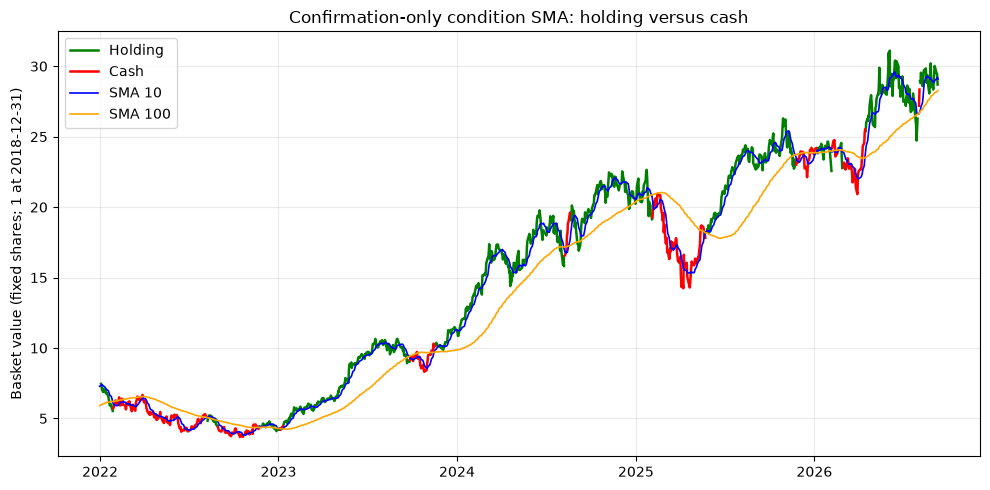


Confirmation-only before-fee/tax performance statistics:
Final equity ($)             27721.403811
Before-fee/tax return (%)      177.214038
CAGR (%)                        24.253326
Annual volatility (%)           31.408508
Sharpe (rf=0)                    0.852383
Sortino (target=0)               1.253187
Maximum drawdown (%)           -35.559779
Drawdown peak                  2021-12-31
Drawdown trough                2022-12-28
Trades                                 11
Wins                                    5
Losses                                  6
Average gross P/L ($)          1611.03671
Exposure (%)                    66.893039
Beta vs SPY                      0.801496
Excess vs SPY (pp)             107.177795
Excess vs SPY ($)            10717.779477

Confirmation-only realised trades:
entry_date  exit_date  entry_price  exit_price entry_reason          exit_reason signal_date  fill_date    gross_pnl  return_pct
2022-01-03 2022-01-28     7.457923    5.718022  trend_entry    

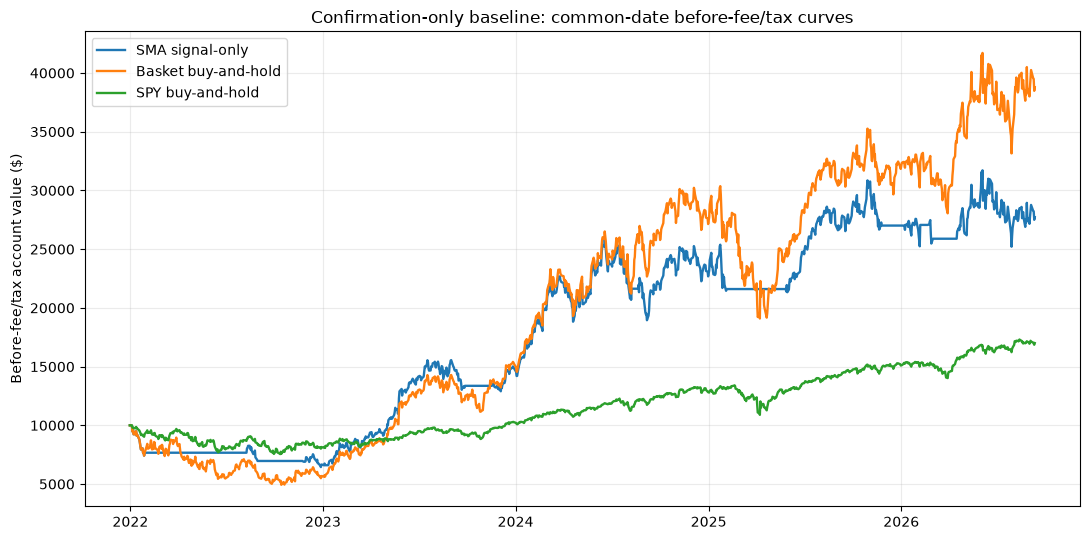

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

N1 = 10
N2 = 100
STARTING_CASH = 10000.0
# Before-fee/tax analysis: retain the shared commission mechanics internally,
# but charge no trading fees (not a tuned fee assumption).
COMMISSION = 0.0
if COMMISSION != 0.0:
    raise RuntimeError("Before-fee/tax notebook runs require COMMISSION=0.0.")
EVAL_START = pd.Timestamp("2021-12-31")
EVAL_END = pd.Timestamp("2026-09-11")
BASKET_ANCHOR = pd.Timestamp("2018-12-31")

assert buy_list, "buy_list is empty"
assert APPROVE_BUY_LIST, "Set APPROVE_BUY_LIST = True first"
if set(map(str, buy_list)) != {"BLDR", "MRVL", "NVDA"}:
    raise ValueError(
        "The approved frozen screen must be exactly BLDR, MRVL, and NVDA; "
        f"received {list(buy_list)}."
    )
if not (isinstance(N1, (int, np.integer)) and isinstance(N2, (int, np.integer))
        and 1 <= N1 <= N2):
    raise ValueError("N1 and N2 must satisfy 1 <= N1 <= N2.")

# Read the existing adjusted-close cache only.  Stock prices are never redownloaded
# or overwritten in any strategy cell.
_cache_file = Path(CACHE_PATH) if "CACHE_PATH" in globals() else Path("return.csv")
if not _cache_file.exists():
    raise FileNotFoundError(f"The adjusted-close cache was not found: {_cache_file}")
cache_prices = pd.read_csv(_cache_file, index_col=0, parse_dates=True)
cache_prices.index = pd.DatetimeIndex(cache_prices.index).tz_localize(None)
if cache_prices.index.has_duplicates:
    raise ValueError("return.csv contains duplicate dates; refusing to choose one silently.")
cache_prices = cache_prices.sort_index()
selected_tickers = list(dict.fromkeys(map(str, buy_list)))
missing_tickers = [t for t in selected_tickers if t not in cache_prices.columns]
if missing_tickers:
    raise ValueError("Selected names missing from return.csv: " + ", ".join(missing_tickers))
required_dates = pd.DatetimeIndex([BASKET_ANCHOR, EVAL_START, EVAL_END])
if not required_dates.isin(cache_prices.index).all():
    missing = [str(d.date()) for d in required_dates if d not in cache_prices.index]
    raise ValueError("Required dates missing from return.csv: " + ", ".join(missing))
price_window = cache_prices.loc["2016-12-31":"2026-09-11", selected_tickers].astype(float)
if price_window.empty or price_window.isna().any().any():
    raise ValueError("Selected names have incomplete prices in the required cache window.")
if not np.isfinite(price_window.to_numpy()).all() or (price_window <= 0).any().any():
    raise ValueError("Selected names have non-finite or non-positive cached prices.")

# One shared fixed-share basket: equal weight at 2018-12-31 and drift thereafter.
fixed_basket_shares = (1.0 / len(selected_tickers)) / price_window.loc[BASKET_ANCHOR]
shared_basket = price_window.mul(fixed_basket_shares, axis=1).sum(axis=1).rename("basket")
shared_fast = shared_basket.rolling(N1).mean().rename(f"SMA{N1}")
shared_slow = shared_basket.rolling(N2).mean().rename(f"SMA{N2}")
basket = shared_basket.loc[EVAL_START:EVAL_END]
sma1 = shared_fast.reindex(basket.index)
sma2 = shared_slow.reindex(basket.index)
if sma1.isna().any() or sma2.isna().any():
    raise ValueError("Insufficient full-history basket data for the selected SMA lengths.")

# Only the benchmark is downloaded here; no stock cache write occurs.
benchmark_raw = yf.download(
    "SPY", start="2021-12-31", end="2026-09-12",
    auto_adjust=True, progress=False, threads=False,
)
if benchmark_raw.empty or "Close" not in benchmark_raw:
    raise ValueError("Yahoo returned no SPY close data for the evaluation window.")
benchmark_close = benchmark_raw["Close"]
if isinstance(benchmark_close, pd.DataFrame):
    benchmark_close = benchmark_close["SPY"] if "SPY" in benchmark_close else benchmark_close.iloc[:, 0]
benchmark_close.index = pd.DatetimeIndex(benchmark_close.index).tz_localize(None)
spy = benchmark_close.reindex(basket.index).astype(float).rename("SPY")
if spy.isna().any() or not np.isfinite(spy.to_numpy()).all() or (spy <= 0).any():
    raise ValueError("SPY has missing or invalid prices on the common basket dates.")

strategy_rolling_high = pd.Series(
    [shared_basket.loc[d - pd.DateOffset(years=3):d].max() for d in shared_basket.index],
    index=shared_basket.index,
    name="rolling_3y_high",
)
strategy_drawdown = (shared_basket / strategy_rolling_high - 1.0).rename("drawdown")

def _validate_signed_fraction(name, value):
    """Require user-facing negative fractions; convert nothing silently."""
    if isinstance(value, bool) or not np.isscalar(value):
        raise ValueError(f"{name} must be a scalar signed fraction in (-1, 0).")
    value = float(value)
    if not np.isfinite(value) or not (-1.0 < value < 0.0):
        raise ValueError(f"{name} must be a finite negative fraction in (-1, 0); got {value!r}.")
    return value

def _aligned_series(value, index, name):
    if isinstance(value, pd.Series):
        result = value.copy()
        if isinstance(result.index, pd.DatetimeIndex):
            result.index = pd.DatetimeIndex(result.index).tz_localize(None)
        result = result.reindex(index)
    else:
        values = np.asarray(value, dtype=float)
        if len(values) != len(index):
            raise ValueError(f"{name} must have {len(index)} observations.")
        result = pd.Series(values, index=index)
    return pd.to_numeric(result, errors="coerce").astype(float).rename(name)

def simulate_condition_strategy(
    prices, fast, slow, drawdowns, mode="sma", entry_drawdown=None,
    stop_loss=None, initial_cash=STARTING_CASH, commission=COMMISSION,
    start_date=None, end_date=None, require_post_stop_crossover=False,
):
    """Common next-close simulator used by every strategy comparison.

    mode='sma' is the confirmation-only condition baseline.  mode='overlay'
    adds the fast/slow trend entry and signed-threshold recovery entry.  A
    signed stop_loss is optional and, when supplied, is checked before every
    other holding transition for both trend and recovery holdings.  The
    risk-only post-stop option requires a fresh bullish SMA crossover after the
    actual stop fill before any trend re-entry; drawdown reset alone never
    unlocks it.
    """
    if mode not in {"sma", "overlay", "buyhold"}:
        raise ValueError("mode must be 'sma', 'overlay', or 'buyhold'.")
    if mode == "overlay":
        entry_drawdown = _validate_signed_fraction("entry_drawdown", entry_drawdown)
    if stop_loss is not None:
        stop_loss = _validate_signed_fraction("stop_loss", stop_loss)
    if require_post_stop_crossover and not (mode == "overlay" and stop_loss is not None):
        raise ValueError("require_post_stop_crossover is only valid for the stopped overlay.")
    if initial_cash <= 0 or commission < 0:
        raise ValueError("initial_cash must be positive and commission non-negative.")

    if isinstance(prices, pd.Series):
        price_series = prices.copy()
        if isinstance(price_series.index, pd.DatetimeIndex):
            price_series.index = pd.DatetimeIndex(price_series.index).tz_localize(None)
        price_series = price_series.sort_index().astype(float)
    else:
        values = np.asarray(prices, dtype=float)
        price_series = pd.Series(values, index=pd.RangeIndex(len(values)))
    if price_series.index.has_duplicates or not price_series.index.is_monotonic_increasing:
        raise ValueError("prices must have a unique, sorted index.")
    if price_series.isna().any() or not np.isfinite(price_series.to_numpy()).all() or (price_series <= 0).any():
        raise ValueError("prices contains missing, non-finite, or non-positive observations.")
    index = price_series.index
    fast_series = _aligned_series(fast, index, "fast")
    slow_series = _aligned_series(slow, index, "slow")
    drawdown_series = _aligned_series(drawdowns, index, "drawdowns")
    if start_date is None:
        start_date = index[0]
    if end_date is None:
        end_date = index[-1]
    if isinstance(index, pd.DatetimeIndex):
        start_date, end_date = pd.Timestamp(start_date), pd.Timestamp(end_date)
    else:
        start_date, end_date = int(start_date), int(end_date)
    eval_index = index[(index >= start_date) & (index <= end_date)]
    if len(eval_index) < 2:
        raise ValueError("The evaluation window needs at least two trading dates.")
    signal_index = eval_index[:-1]
    for name, series in [("fast", fast_series), ("slow", slow_series), ("drawdowns", drawdown_series)]:
        if not np.isfinite(series.loc[signal_index].to_numpy()).all():
            raise ValueError(f"{name} is missing or non-finite on signal dates.")

    cash = float(initial_cash)
    units = 0.0
    state = "flat"
    entry_price = entry_cost = entry_date = entry_reason = None
    recovery_disabled = False
    post_stop_restricted = False
    last_sell_date = None
    commission_total = 0.0
    equity_values, exposure_values, state_values, cash_values = [], [], [], []
    signal_rows, trade_rows = [], []

    def close_trade(fill_date, fill_price, reason, signal_date):
        nonlocal cash, units, commission_total
        nonlocal entry_price, entry_cost, entry_date, entry_reason
        gross = units * fill_price
        exit_fee = gross * commission
        cash += gross - exit_fee
        commission_total += exit_fee
        trade_rows.append({
            "entry_date": entry_date, "exit_date": fill_date,
            "entry_price": entry_price, "exit_price": fill_price,
            "entry_reason": entry_reason, "exit_reason": reason,
            "signal_date": signal_date, "fill_date": fill_date,
            # Kept as net_pnl for compatibility; with COMMISSION=0 this is gross P/L.
            "net_pnl": gross - exit_fee - entry_cost,
            "return_pct": 100.0 * ((gross - exit_fee) / entry_cost - 1.0),
            "commission": (entry_cost - units * entry_price) + exit_fee,
        })
        units = 0.0
        entry_price = entry_cost = entry_date = entry_reason = None

    for i, date in enumerate(eval_index):
        price = float(price_series.loc[date])
        action = reason = next_state = signal_date = None
        if i > 0:
            signal_date = eval_index[i - 1]
            signal_price = float(price_series.loc[signal_date])
            signal_fast = float(fast_series.loc[signal_date])
            signal_slow = float(slow_series.loc[signal_date])
            signal_dd = float(drawdown_series.loc[signal_date])
            if (
                mode == "overlay"
                and not require_post_stop_crossover
                and recovery_disabled
                and signal_dd > entry_drawdown
            ):
                recovery_disabled = False
            previous_signal_date = eval_index[i - 2] if i >= 2 else None
            fresh_bullish_crossover = (
                previous_signal_date is not None
                and float(fast_series.loc[previous_signal_date])
                    <= float(slow_series.loc[previous_signal_date])
                and signal_fast > signal_slow
            )

            if mode == "buyhold":
                if i == 1:
                    action, reason, next_state = "buy", "buy_and_hold_entry", "buyhold"
            elif i < len(eval_index) - 1:
                if units > 0.0:
                    # Stop priority is explicit and applies to all holdings.
                    if (
                        stop_loss is not None
                        and signal_price / entry_price - 1.0 <= stop_loss + 1e-12
                    ):
                        action, reason = "sell", "stop_loss"
                    elif state == "trend" and signal_fast < signal_slow:
                        action, reason = "sell", "sma_bearish_exit"
                    elif state == "recovery" and signal_fast > signal_slow:
                        state = "trend"
                        signal_rows.append({
                            "action": "state_change", "signal_date": signal_date,
                            "fill_date": pd.NaT, "reason": "recovery_to_trend",
                        })
                else:
                    trend_entry_allowed = signal_fast > signal_slow
                    if (
                        mode == "overlay"
                        and require_post_stop_crossover
                        and post_stop_restricted
                    ):
                        trend_entry_allowed = fresh_bullish_crossover
                    if trend_entry_allowed:
                        action, reason, next_state = "buy", "trend_entry", "trend"
                    elif (
                        mode == "overlay"
                        and not recovery_disabled
                        and not post_stop_restricted
                        and signal_dd <= entry_drawdown
                    ):
                        action, reason, next_state = "buy", "recovery_entry", "recovery"

        if action == "buy" and units == 0.0 and date != last_sell_date:
            units = cash / (price * (1.0 + commission))
            gross = units * price
            entry_fee = gross * commission
            cash = max(0.0, cash - gross - entry_fee)
            commission_total += entry_fee
            entry_price, entry_cost = price, gross + entry_fee
            entry_date, entry_reason, state = date, reason, next_state
            signal_rows.append({
                "action": "buy", "signal_date": signal_date,
                "fill_date": date, "reason": reason,
            })
        elif action == "buy" and date == last_sell_date:
            signal_rows.append({
                "action": "blocked_buy", "signal_date": signal_date,
                "fill_date": date, "reason": "same_day_after_sell",
            })
        elif action == "sell" and units > 0.0:
            close_trade(date, price, reason, signal_date)
            last_sell_date = date
            signal_rows.append({
                "action": "sell", "signal_date": signal_date,
                "fill_date": date, "reason": reason,
            })
            if mode == "overlay" and reason == "stop_loss":
                if require_post_stop_crossover:
                    # This lock is intentionally independent of drawdown reset.
                    post_stop_restricted = True
                    recovery_disabled = True
                else:
                    recovery_disabled = not (float(drawdown_series.loc[signal_date]) > entry_drawdown)
            elif (
                mode == "overlay"
                and require_post_stop_crossover
                and reason == "sma_bearish_exit"
            ):
                # A permitted SMA trade has completed normally: restore all
                # condition-based trend and drawdown entries.
                post_stop_restricted = False
                recovery_disabled = False
            state = "flat"

        if date == eval_index[-1] and units > 0.0:
            close_trade(date, price, "terminal_liquidation", pd.NaT)
            signal_rows.append({
                "action": "sell", "signal_date": pd.NaT,
                "fill_date": date, "reason": "terminal_liquidation",
            })
            state = "flat"
        equity_values.append(cash + units * price)
        cash_values.append(cash)
        exposure_values.append(float(units > 0.0))
        state_values.append(state)

    equity = pd.Series(equity_values, index=eval_index, name="equity")
    exposure = pd.Series(exposure_values, index=eval_index, name="exposure")
    state_series = pd.Series(state_values, index=eval_index, name="state")
    signals = pd.DataFrame(signal_rows)
    trades = pd.DataFrame(trade_rows)
    if trades.empty:
        trades = pd.DataFrame(columns=[
            "entry_date", "exit_date", "entry_price", "exit_price",
            "entry_reason", "exit_reason", "signal_date", "fill_date",
            "net_pnl", "return_pct", "commission",
        ])
    return {
        "equity": equity,
        "trades": trades,
        "signals": signals,
        "diagnostics": {
            "exposure": exposure, "state": state_series, "signals": signals,
            "cash": pd.Series(cash_values, index=eval_index, name="cash"),
            "commission_total": float(commission_total), "mode": mode,
        },
    }

def _max_drawdown_dates(equity):
    dd = equity / equity.cummax() - 1.0
    trough = dd.idxmin()
    peak = equity.loc[:trough].idxmax()
    return float(dd.loc[trough] * 100.0), peak, trough

def strategy_metrics(label, result, benchmark_result=None):
    equity = result["equity"]
    daily = equity.pct_change(fill_method=None).dropna()
    years = max((equity.index[-1] - equity.index[0]).days / 365.25, 1.0 / 365.25)
    std = daily.std()
    downside = np.sqrt(daily.clip(upper=0).pow(2).mean())
    dd, dd_peak, dd_trough = _max_drawdown_dates(equity)
    trades = result["trades"]
    wins = int((trades["net_pnl"] > 0).sum()) if len(trades) else 0
    losses = int((trades["net_pnl"] < 0).sum()) if len(trades) else 0
    if benchmark_result is None:
        beta, excess_pp, excess_dollars = np.nan, np.nan, np.nan
    else:
        benchmark_daily = benchmark_result["equity"].pct_change(fill_method=None).dropna()
        pair = pd.concat([daily.rename("strategy"), benchmark_daily.rename("benchmark")], axis=1).dropna()
        beta = pair["strategy"].cov(pair["benchmark"]) / pair["benchmark"].var()
        excess_pp = 100.0 * (equity.iloc[-1] / STARTING_CASH - benchmark_result["equity"].iloc[-1] / STARTING_CASH)
        excess_dollars = equity.iloc[-1] - benchmark_result["equity"].iloc[-1]
    return {
        "Final equity ($)": equity.iloc[-1],
        "Before-fee/tax return (%)": 100.0 * (equity.iloc[-1] / STARTING_CASH - 1.0),
        "CAGR (%)": 100.0 * ((equity.iloc[-1] / STARTING_CASH) ** (1.0 / years) - 1.0),
        "Annual volatility (%)": 100.0 * std * np.sqrt(252),
        "Sharpe (rf=0)": daily.mean() / std * np.sqrt(252) if std else np.nan,
        "Sortino (target=0)": daily.mean() / downside * np.sqrt(252) if downside else np.nan,
        "Maximum drawdown (%)": dd,
        "Drawdown peak": dd_peak.date().isoformat(),
        "Drawdown trough": dd_trough.date().isoformat(),
        "Trades": len(trades),
        "Wins": wins,
        "Losses": losses,
        "Average gross P/L ($)": trades["net_pnl"].mean() if len(trades) else np.nan,
        "Exposure (%)": 100.0 * result["diagnostics"]["exposure"].mean(),
        "Beta vs SPY": beta,
        "Excess vs SPY (pp)": excess_pp,
        "Excess vs SPY ($)": excess_dollars,
    }

def _display_trades(result):
    """Return user-facing gross trade results without the internal cost column."""
    return result["trades"].drop(columns=["commission"], errors="ignore").rename(
        columns={"net_pnl": "gross_pnl"}
    )

def plot_holding_chart(result, title):
    hold = result["diagnostics"]["exposure"].astype(bool)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(basket.where(hold), color="green", lw=1.8, label="Holding")
    ax.plot(basket.where(~hold), color="red", lw=1.8, label="Cash")
    ax.plot(sma1, color="blue", lw=1.2, label=f"SMA {N1}")
    ax.plot(sma2, color="orange", lw=1.2, label=f"SMA {N2}")
    ax.set_title(title)
    ax.set_ylabel("Basket value (fixed shares; 1 at 2018-12-31)")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_net_curves(curves, title):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for label, series in curves.items():
        ax.plot(series, lw=1.7, label=label)
    ax.set_title(title)
    ax.set_ylabel("Before-fee/tax account value ($)")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

# All strategies use identical dates, cash, next-close timing, zero costs, and liquidation.
confirmation_result = simulate_condition_strategy(
    basket, sma1, sma2, strategy_drawdown.reindex(basket.index),
    mode="sma", initial_cash=STARTING_CASH, commission=COMMISSION,
    start_date=EVAL_START, end_date=EVAL_END,
)
buyhold_result = simulate_condition_strategy(
    basket, sma1, sma2, strategy_drawdown.reindex(basket.index),
    mode="buyhold", initial_cash=STARTING_CASH, commission=COMMISSION,
    start_date=EVAL_START, end_date=EVAL_END,
)
spy_dummy = pd.Series(0.0, index=spy.index)
spy_result = simulate_condition_strategy(
    spy, spy_dummy, spy_dummy, spy_dummy,
    mode="buyhold", initial_cash=STARTING_CASH, commission=COMMISSION,
    start_date=EVAL_START, end_date=EVAL_END,
)
confirmation_stats = strategy_metrics("SMA signal-only", confirmation_result, spy_result)
buyhold_stats = strategy_metrics("Basket buy-and-hold", buyhold_result, spy_result)
spy_stats = strategy_metrics("SPY buy-and-hold", spy_result, spy_result)

confirmed = sma1 > sma2
# Account growth uses each buy-and-hold strategy's actual first fill and
# terminal liquidation, rather than the displayed 2021-12-31 price bar.
spy_gross = spy_result["equity"] / STARTING_CASH
basket_gross = buyhold_result["equity"] / STARTING_CASH
print("One fixed-share basket: equal-weight on 2018-12-31, then drift; no 2021 reset.")
print(f"Frozen names: {', '.join(selected_tickers)} | cache: {_cache_file}")
print(f"Latest status: {'ON' if bool(confirmed.iloc[-1]) else 'OFF'} ({basket.index[-1].date()})")
print(f"Latest SMA{N1}: {sma1.iloc[-1]:.6f} | SMA{N2}: {sma2.iloc[-1]:.6f}")
print("\nGross benchmark/basket growth and before-fee/tax signal-account growth:")
print(pd.Series({
    "SPY buy-and-hold": spy_gross.iloc[-1],
    "Basket always held": basket_gross.iloc[-1],
    "SMA signal-only before fees/tax": (confirmation_result["equity"].iloc[-1] / STARTING_CASH),
}).round(4).to_string())
plot_holding_chart(confirmation_result, "Confirmation-only condition SMA: holding versus cash")
print("\nConfirmation-only before-fee/tax performance statistics:")
print(pd.Series(confirmation_stats).to_string())
print("\nConfirmation-only realised trades:")
print(_display_trades(confirmation_result).to_string(index=False))
plot_net_curves({
    "SMA signal-only": confirmation_result["equity"],
    "Basket buy-and-hold": buyhold_result["equity"],
    "SPY buy-and-hold": spy_result["equity"],
}, "Confirmation-only baseline: common-date before-fee/tax curves")


In [6]:
print("Latest confirmation status:", "ON" if bool(confirmed.iloc[-1]) else "OFF")
print("Last date:", basket.index[-1].date())
print(f"SMA{N1}: {sma1.iloc[-1]:.6f}")
print(f"SMA{N2}: {sma2.iloc[-1]:.6f}")


Latest confirmation status: ON
Last date: 2026-09-11
SMA10: 29.083783
SMA100: 28.269707


In [7]:
print("Gross diagnostic only; all account comparisons are before trading fees and tax; terminal liquidation has no cost.")
pd.DataFrame({
    "SPY buy-and-hold": [spy_gross.iloc[-1]],
    "Basket always held": [basket_gross.iloc[-1]],
    "SMA signal-only before fees/tax": [confirmation_result["equity"].iloc[-1] / STARTING_CASH],
}, index=["Growth of $1"])


Gross diagnostic only; all account comparisons are before trading fees and tax; terminal liquidation has no cost.


,SPY buy-and-hold,Basket always held,SMA signal-only before fees/tax
Growth of $1,1.700362,3.879147,2.77214


In [8]:
print("Confirmation-only condition-based SMA performance:")
print(pd.Series(confirmation_stats).to_string())


Confirmation-only condition-based SMA performance:
Final equity ($)             27721.403811
Before-fee/tax return (%)      177.214038
CAGR (%)                        24.253326
Annual volatility (%)           31.408508
Sharpe (rf=0)                    0.852383
Sortino (target=0)               1.253187
Maximum drawdown (%)           -35.559779
Drawdown peak                  2021-12-31
Drawdown trough                2022-12-28
Trades                                 11
Wins                                    5
Losses                                  6
Average gross P/L ($)          1611.03671
Exposure (%)                    66.893039
Beta vs SPY                      0.801496
Excess vs SPY (pp)             107.177795
Excess vs SPY ($)            10717.779477


In [9]:
print("Confirmation-only realised trades:")
confirmation_result["trades"]


Confirmation-only realised trades:


,entry_date,exit_date,entry_price,exit_price,entry_reason,exit_reason,signal_date,fill_date,net_pnl,return_pct,commission
0,2022-01-03,2022-01-28,7.457923,5.718022,trend_entry,sma_bearish_exit,2022-01-27,2022-01-28,-2332.956755,-23.329568,0.0
1,2022-08-09,2022-08-30,4.838873,4.395728,trend_entry,sma_bearish_exit,2022-08-29,2022-08-30,-702.149728,-9.158025,0.0
2,2022-11-23,2023-01-05,4.430939,4.200392,trend_entry,sma_bearish_exit,2023-01-04,2023-01-05,-362.391163,-5.203111,0.0
3,2023-01-11,2023-09-27,4.523468,9.155401,trend_entry,sma_bearish_exit,2023-09-26,2023-09-27,6760.819720,102.397839,0.0
4,2023-11-17,2024-08-08,10.222449,16.547568,trend_entry,sma_bearish_exit,2024-08-07,2024-08-08,8268.527011,61.874787,0.0
5,2024-08-20,2025-02-04,19.302081,19.276151,trend_entry,sma_bearish_exit,2025-02-03,2025-02-04,-29.060330,-0.134340,0.0
6,2025-05-27,2025-11-25,18.411796,23.018982,trend_entry,sma_bearish_exit,2025-11-24,2025-11-25,5405.667375,25.023007,0.0
7,2026-01-06,2026-02-06,24.141179,24.190395,trend_entry,sma_bearish_exit,2026-02-05,2026-02-06,55.061660,0.203868,0.0
8,2026-02-20,2026-03-02,24.193672,23.143568,trend_entry,sma_bearish_exit,2026-02-27,2026-03-02,-1174.666462,-4.340406,0.0
9,2026-04-16,2026-08-03,25.392782,27.195854,trend_entry,sma_bearish_exit,2026-07-31,2026-08-03,1838.296515,7.100726,0.0


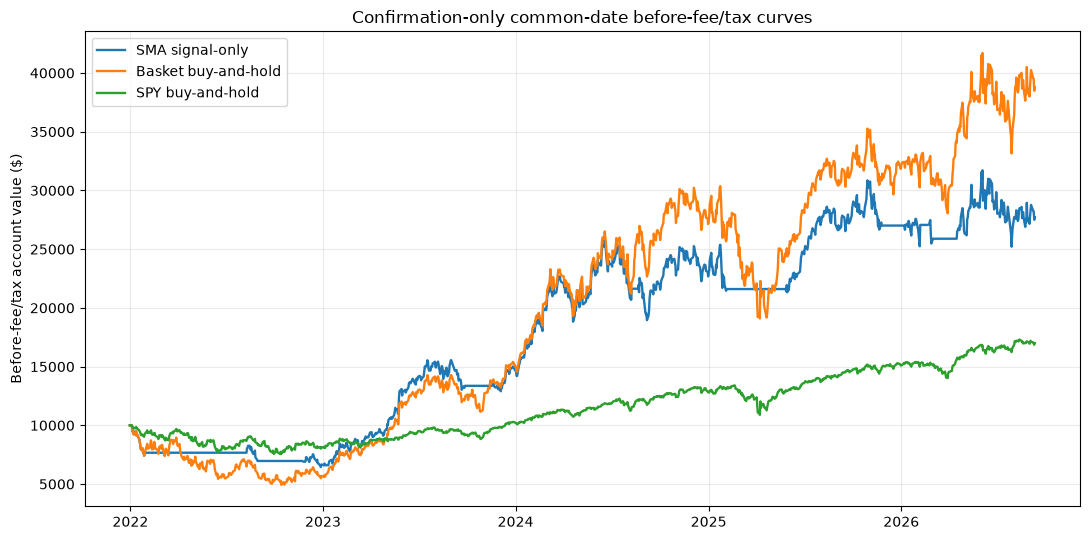

In [10]:
plot_net_curves({
    "SMA signal-only": confirmation_result["equity"],
    "Basket buy-and-hold": buyhold_result["equity"],
    "SPY buy-and-hold": spy_result["equity"],
}, "Confirmation-only common-date before-fee/tax curves")


## Pre-entry basket maximum-drawdown episodes

This diagnostic uses the same fixed-share basket as every strategy: equal-weight
on **2018-12-31**, fixed shares thereafter, and retrospective pre-2018 backcast.
The window is 2016-12-31 through 2021-12-31 (the actual first available trading
date is printed).  Each contiguous underwater episode contributes only its
maximum peak-to-trough loss.  The final episode is **censored** if it has not
recovered by 2021-12-31; all other episodes are **completed**.

The chart and the compact count table use five mutually exclusive magnitude
bands.  Boundaries are explicit: `<5%`, `5% to <10%`, `10% to <15%`,
`15% to <20%`, and `>=20%` (so exactly 5%, 10%, 15%, and 20% have one
unambiguous band).  Only counts are printed; no large individual episode table
is emitted.  This is a threshold diagnostic, not an optimisation or a claim of
future safety.

3-year drawdown mostly within -10%.


Diagnostic window: requested 2016-12-31 to 2021-12-31; actual dates 2017-01-03 to 2021-12-31
Frozen names: BLDR, MRVL, NVDA; basket starts 2017-01-03

Maximum-drawdown episode counts (mutually exclusive; no individual episode rows):
                                        Completed  Censored  Total
Maximum drawdown band (loss magnitude)                            
<5%                                            64         1     65
5% to <10%                                     15         0     15
10% to <15%                                     4         0      4
15% to <20%                                     1         0      1
>=20% (20%+)                                    2         0      2


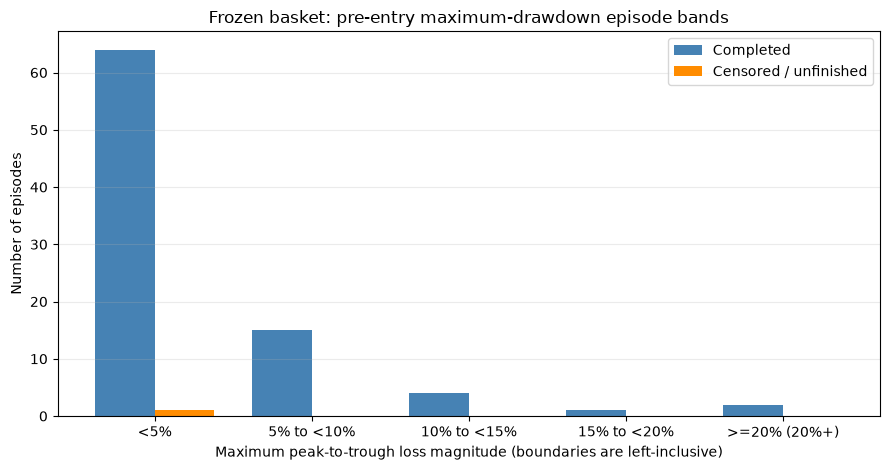

In [11]:
# Read-only diagnostic: this cell never downloads prices or writes return.csv.
prehistory = shared_basket.loc["2016-12-31":"2021-12-31"]
if prehistory.empty:
    raise ValueError("The requested pre-entry window is empty.")
print(
    "Diagnostic window: requested 2016-12-31 to 2021-12-31; "
    f"actual dates {prehistory.index[0].date()} to {prehistory.index[-1].date()}"
)
print(f"Frozen names: {', '.join(selected_tickers)}; basket starts {shared_basket.index[0].date()}")

prehistory_high = prehistory.cummax()
prehistory_dd = prehistory / prehistory_high - 1.0
underwater = prehistory_dd < 0.0
episode_id = underwater.ne(underwater.shift(fill_value=False)).cumsum()
episode_rows = []
for _, part in prehistory_dd[underwater].groupby(episode_id[underwater]):
    start_date, last_underwater = part.index[0], part.index[-1]
    start_pos = prehistory.index.get_loc(start_date)
    prior = prehistory.iloc[:start_pos]
    if prior.empty:
        raise ValueError(f"Could not identify the peak before {start_date.date()}.")
    peak_level = prior.max()
    peak_date = prior[prior == peak_level].index[-1]
    trough_date = part.idxmin()
    recovery_dates = prehistory.index[prehistory.index > last_underwater]
    recovered = recovery_dates[prehistory_dd.reindex(recovery_dates) >= 0.0]
    recovery_date = recovered[0] if len(recovered) else pd.NaT
    episode_rows.append({
        "peak_date": peak_date, "trough_date": trough_date,
        "recovery_date": recovery_date,
        "drawdown_pct": -100.0 * float(part.loc[trough_date]),
        "censored": pd.isna(recovery_date),
    })
drawdown_episodes = pd.DataFrame(episode_rows)
if drawdown_episodes.empty:
    drawdown_episodes = pd.DataFrame(columns=["drawdown_pct", "censored"])

band_labels = ["<5%", "5% to <10%", "10% to <15%", "15% to <20%", ">=20% (20%+)" ]
band_edges = [-np.inf, 5.0, 10.0, 15.0, 20.0, np.inf]
drawdown_episodes["band"] = pd.cut(
    drawdown_episodes["drawdown_pct"], bins=band_edges, labels=band_labels,
    right=False, include_lowest=True,
)
episode_counts = pd.DataFrame({
    "Completed": drawdown_episodes.loc[~drawdown_episodes["censored"]].groupby(
        "band", observed=False
    ).size(),
    "Censored": drawdown_episodes.loc[drawdown_episodes["censored"]].groupby(
        "band", observed=False
    ).size(),
}, index=pd.CategoricalIndex(band_labels, categories=band_labels, ordered=True)).fillna(0).astype(int)
episode_counts["Total"] = episode_counts["Completed"] + episode_counts["Censored"]
episode_counts.index.name = "Maximum drawdown band (loss magnitude)"
print("\nMaximum-drawdown episode counts (mutually exclusive; no individual episode rows):")
print(episode_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(band_labels))
width = 0.38
ax.bar(x - width / 2, episode_counts["Completed"], width, label="Completed", color="steelblue")
ax.bar(x + width / 2, episode_counts["Censored"], width, label="Censored / unfinished", color="darkorange")
ax.set_xticks(x, band_labels)
ax.set_xlabel("Maximum peak-to-trough loss magnitude (boundaries are left-inclusive)")
ax.set_ylabel("Number of episodes")
ax.set_title("Frozen basket: pre-entry maximum-drawdown episode bands")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## Trading rules — signal plus drawdown, **no stop loss**

`ENTRY_DRAWDOWN` is the editable signed threshold at the start of the next
cell.  It is negative by design: `-0.15` means the basket is at or below a
15% drawdown from its trailing three-calendar-year high.  The simulator
validates signed fractions and passes magnitudes internally only where an
arithmetic comparison needs one.

On the previous close, a flat book enters **trend** when `fast SMA > slow SMA`.
If that is false, it enters **recovery** when drawdown `<= ENTRY_DRAWDOWN`.
Both entries fill at the next trading-day basket-price proxy.  A trend holding
exits on a bearish `fast SMA < slow SMA` signal.  A recovery holding does **not**
exit merely because the SMA is bearish: it waits until `fast SMA > slow SMA`,
transfers to trend, and then uses the same bearish SMA exit.  There is no stop
loss in this section.  The book is long-only, all-cash or one full basket, with
no leverage, averaging down, DCA, or rebalance; a terminal liquidation is
executed at no cost.

The cell reports the same breadth as confirmation: latest status/SMAs, growth
values, holding/cash coloured basket chart with SMA lines, performance statistics,
realised trades, and common-date before-fee/tax curves.  It also provides the no-stop
strategy used in the later head-to-head table.


No-stop rule: trend if SMA10 > SMA100; otherwise recovery if drawdown <= -15.0%.
Latest SMA status: ON (2026-09-11)
Latest SMA10: 29.083783 | SMA100: 28.269707

Growth of $1 / before-fee/tax account growth:
SPY buy-and-hold gross                       1.7004
Basket always held gross                     3.8791
Confirmation-only before fees/tax            2.7721
Signal + drawdown no-stop before fees/tax    3.7730


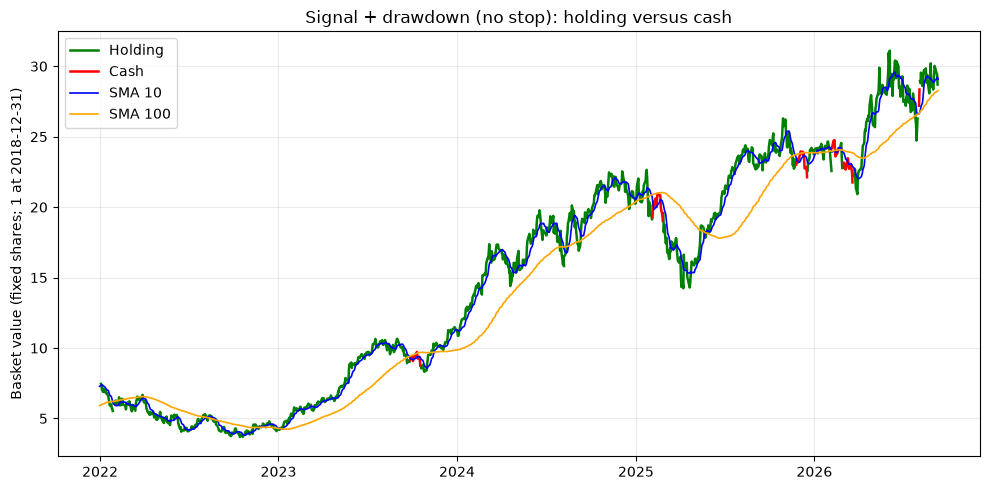


Signal + drawdown no-stop before-fee/tax performance statistics:
Final equity ($)             37729.763146
Before-fee/tax return (%)      277.297631
CAGR (%)                        32.684007
Annual volatility (%)           41.656958
Sharpe (rf=0)                    0.890497
Sortino (target=0)               1.313485
Maximum drawdown (%)           -52.180849
Drawdown peak                  2021-12-31
Drawdown trough                2022-10-14
Trades                                 11
Wins                                    6
Losses                                  5
Average gross P/L ($)         2520.887559
Exposure (%)                    93.293718
Beta vs SPY                      1.856266
Excess vs SPY (pp)             207.261388
Excess vs SPY ($)            20726.138812

Signal + drawdown no-stop realised trades:
entry_date  exit_date  entry_price  exit_price   entry_reason          exit_reason signal_date  fill_date    gross_pnl  return_pct
2022-01-03 2022-01-28     7.457923    5.71802

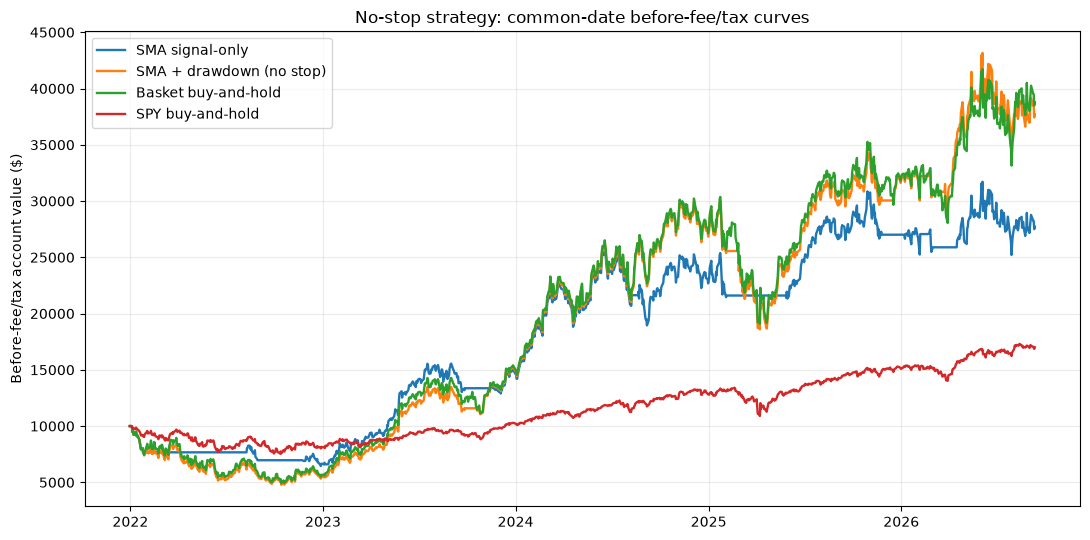

In [12]:
ENTRY_DRAWDOWN = -0.15
# Editable signed parameter for the no-stop trading-rules section.
ENTRY_DRAWDOWN = _validate_signed_fraction("ENTRY_DRAWDOWN", ENTRY_DRAWDOWN)

no_stop_result = simulate_condition_strategy(
    basket, sma1, sma2, strategy_drawdown.reindex(basket.index),
    mode="overlay", entry_drawdown=ENTRY_DRAWDOWN, stop_loss=None,
    initial_cash=STARTING_CASH, commission=COMMISSION,
    start_date=EVAL_START, end_date=EVAL_END,
)
no_stop_stats = strategy_metrics("SMA + drawdown (no stop)", no_stop_result, spy_result)
no_stop_confirmed = sma1 > sma2
print(
    f"No-stop rule: trend if SMA{N1} > SMA{N2}; otherwise recovery if "
    f"drawdown <= {ENTRY_DRAWDOWN:.1%}."
)
print(f"Latest SMA status: {'ON' if bool(no_stop_confirmed.iloc[-1]) else 'OFF'} ({basket.index[-1].date()})")
print(f"Latest SMA{N1}: {sma1.iloc[-1]:.6f} | SMA{N2}: {sma2.iloc[-1]:.6f}")
print("\nGrowth of $1 / before-fee/tax account growth:")
print(pd.Series({
    "SPY buy-and-hold gross": spy_gross.iloc[-1],
    "Basket always held gross": basket_gross.iloc[-1],
    "Confirmation-only before fees/tax": confirmation_result["equity"].iloc[-1] / STARTING_CASH,
    "Signal + drawdown no-stop before fees/tax": no_stop_result["equity"].iloc[-1] / STARTING_CASH,
}).round(4).to_string())
plot_holding_chart(no_stop_result, "Signal + drawdown (no stop): holding versus cash")
print("\nSignal + drawdown no-stop before-fee/tax performance statistics:")
print(pd.Series(no_stop_stats).to_string())
print("\nSignal + drawdown no-stop realised trades:")
print(_display_trades(no_stop_result).to_string(index=False))
no_stop_head_to_head = pd.DataFrame({
    "Buy and hold": buyhold_stats,
    "SMA signal-only": confirmation_stats,
    "SMA + drawdown (no stop)": no_stop_stats,
})
assert list(no_stop_head_to_head.columns) == [
    "Buy and hold", "SMA signal-only", "SMA + drawdown (no stop)"
]
print("\nNo-stop head-to-head (same basket, dates, cash, timing, zero costs, liquidation):")
print(no_stop_head_to_head.round(4).to_string())
plot_net_curves({
    "SMA signal-only": confirmation_result["equity"],
    "SMA + drawdown (no stop)": no_stop_result["equity"],
    "Basket buy-and-hold": buyhold_result["equity"],
    "SPY buy-and-hold": spy_result["equity"],
}, "No-stop strategy: common-date before-fee/tax curves")


## Risk management overlay — signed stop loss

`STOP_LOSS` begins the next cell and is an editable **negative** fraction:
`-0.10` means exit when the previous-close basket price is at or below 90% of
the actual basket entry price.  Signed validation rejects positive, zero,
non-finite, and out-of-range values.  This is a clear general overlay: the stop
applies to **all holdings**, including trend holdings and recovery holdings,
rather than only recovery entries.  Stop priority is before transfer or SMA
exit.  It is still a daily-close proxy and is not a guaranteed intraday stop
fill.

The risk section reuses the selected no-stop `ENTRY_DRAWDOWN` threshold.  After
**any stop-out**, drawdown entries are disabled and trend re-entry is restricted
until a **fresh bullish SMA crossover** after the actual stop fill:
`fast(previous) <= slow(previous)` and `fast(current) > slow(current)`.  A fast
SMA that is already bullish at the stop cannot trigger immediate re-entry, and
the restriction survives a price drawdown reset.  A permitted SMA trade that
later exits normally on bearish SMA (not stop or terminal liquidation) restores
normal trend and drawdown entries.  If that permitted trade stops, the fresh
crossover restriction starts again.  A stop, bearish exit, and terminal
liquidation cannot trigger same-day re-entry.  Recovery holdings otherwise wait
for bullish SMA transfer, as in the no-stop rule.  The cell reports latest
status/SMAs, growth, the holding/cash chart with SMA lines, performance
statistics, trades, and the head-to-head before-fee/tax curves against buy-and-hold,
signal-only, and signal-plus-drawdown no-stop.


Risk overlay: ENTRY_DRAWDOWN=-15.0%; STOP_LOSS=-10.0%; stop applies to trend and recovery holdings with stop priority.
Post-stop rule: drawdown entries stay disabled and trend re-entry requires a fresh bullish SMA crossover after the actual stop fill.
Latest SMA status: ON (2026-09-11)
Latest SMA10: 29.083783 | SMA100: 28.269707

Growth of $1 / before-fee/tax account growth:
SPY buy-and-hold gross                       1.7004
Basket always held gross                     3.8791
Confirmation-only before fees/tax            2.7721
Signal + drawdown no-stop before fees/tax    3.7730
Signal + drawdown + stop before fees/tax     4.2148


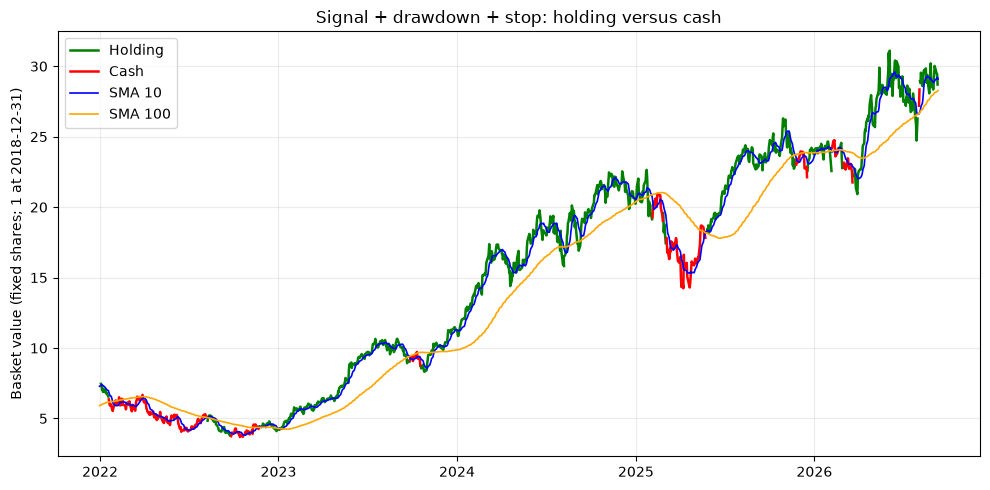


Risk-overlay before-fee/tax performance statistics:
Final equity ($)             42147.990987
Before-fee/tax return (%)       321.47991
CAGR (%)                         35.85045
Annual volatility (%)            32.97997
Sharpe (rf=0)                    1.099477
Sortino (target=0)               1.625123
Maximum drawdown (%)           -37.566699
Drawdown peak                  2021-12-31
Drawdown trough                2022-12-28
Trades                                 13
Wins                                    6
Losses                                  7
Average gross P/L ($)         2472.922384
Exposure (%)                    73.089983
Beta vs SPY                      0.921522
Excess vs SPY (pp)             251.443667
Excess vs SPY ($)            25144.366653

Risk-overlay realised trades:
entry_date  exit_date  entry_price  exit_price   entry_reason          exit_reason signal_date  fill_date    gross_pnl  return_pct
2022-01-03 2022-01-19     7.457923    6.355727    trend_entry          

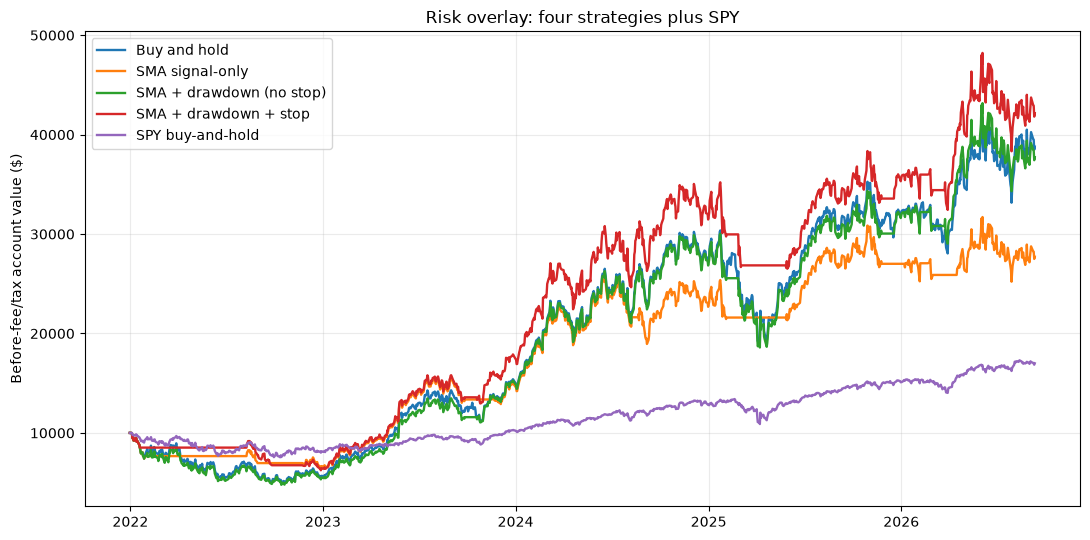

In [13]:
STOP_LOSS = -0.10
# Editable signed risk parameter.  The no-stop threshold is intentionally reused.
STOP_LOSS = _validate_signed_fraction("STOP_LOSS", STOP_LOSS)
if "ENTRY_DRAWDOWN" not in globals():
    raise RuntimeError("Run the no-stop trading-rules cell first to select ENTRY_DRAWDOWN.")
ENTRY_DRAWDOWN = _validate_signed_fraction("ENTRY_DRAWDOWN", ENTRY_DRAWDOWN)

risk_result = simulate_condition_strategy(
    basket, sma1, sma2, strategy_drawdown.reindex(basket.index),
    mode="overlay", entry_drawdown=ENTRY_DRAWDOWN, stop_loss=STOP_LOSS,
    initial_cash=STARTING_CASH, commission=COMMISSION,
    start_date=EVAL_START, end_date=EVAL_END,
    require_post_stop_crossover=True,
)
risk_stats = strategy_metrics("SMA + drawdown + stop", risk_result, spy_result)
print(
    f"Risk overlay: ENTRY_DRAWDOWN={ENTRY_DRAWDOWN:.1%}; STOP_LOSS={STOP_LOSS:.1%}; "
    "stop applies to trend and recovery holdings with stop priority."
)
print(
    "Post-stop rule: drawdown entries stay disabled and trend re-entry requires "
    "a fresh bullish SMA crossover after the actual stop fill."
)
print(f"Latest SMA status: {'ON' if bool((sma1 > sma2).iloc[-1]) else 'OFF'} ({basket.index[-1].date()})")
print(f"Latest SMA{N1}: {sma1.iloc[-1]:.6f} | SMA{N2}: {sma2.iloc[-1]:.6f}")
print("\nGrowth of $1 / before-fee/tax account growth:")
print(pd.Series({
    "SPY buy-and-hold gross": spy_gross.iloc[-1],
    "Basket always held gross": basket_gross.iloc[-1],
    "Confirmation-only before fees/tax": confirmation_result["equity"].iloc[-1] / STARTING_CASH,
    "Signal + drawdown no-stop before fees/tax": no_stop_result["equity"].iloc[-1] / STARTING_CASH,
    "Signal + drawdown + stop before fees/tax": risk_result["equity"].iloc[-1] / STARTING_CASH,
}).round(4).to_string())
plot_holding_chart(risk_result, "Signal + drawdown + stop: holding versus cash")
print("\nRisk-overlay before-fee/tax performance statistics:")
print(pd.Series(risk_stats).to_string())
print("\nRisk-overlay realised trades:")
print(_display_trades(risk_result).to_string(index=False))
risk_head_to_head = pd.DataFrame({
    "Buy and hold": buyhold_stats,
    "SMA signal-only": confirmation_stats,
    "SMA + drawdown (no stop)": no_stop_stats,
    "SMA + drawdown + stop": risk_stats,
})
print("\nRisk-overlay head-to-head:")
print(risk_head_to_head.round(4).to_string())
plot_net_curves({
    "Buy and hold": buyhold_result["equity"],
    "SMA signal-only": confirmation_result["equity"],
    "SMA + drawdown (no stop)": no_stop_result["equity"],
    "SMA + drawdown + stop": risk_result["equity"],
    "SPY buy-and-hold": spy_result["equity"],
}, "Risk overlay: four strategies plus SPY")


## Four-strategy evaluation plus SPY benchmark

The final evaluation compares exactly four basket strategies and the SPY
benchmark on common dates (2021-12-31 through 2026-09-11):

1. basket buy-and-hold;
2. condition-based SMA signal-only confirmation;
3. condition-based SMA plus drawdown recovery entry, **no stop**;
4. the same SMA plus drawdown rules with the general all-holdings stop overlay.

All use the shared fixed-share basket, full-history SMA warmup, $10,000 starting
cash, next-close execution, no trading fees or tax deducted, zero cash interest
and terminal liquidation.  Statistics include whole-account cash time, gross
trades, drawdown peak/trough dates, exposure, beta and excess return versus SPY.
The table and before-fee/tax curves are descriptive in-sample evidence, not a claim
of future superiority.


BEFORE-FEE/TAX HEAD-TO-HEAD: 2021-12-31 to 2026-09-11 | $10,000, next-close proxy, no trading fees or tax deducted, terminal liquidation
                          Basket buy-and-hold SMA signal-only SMA + drawdown (no stop) SMA + drawdown + stop SPY buy-and-hold
Final equity ($)                 38791.470181    27721.403811             37729.763146          42147.990987     17003.624334
Before-fee/tax return (%)          287.914702      177.214038               277.297631             321.47991        70.036243
CAGR (%)                            33.470526       24.253326                32.684007              35.85045        11.969384
Annual volatility (%)               42.444878       31.408508                41.656958              32.97997        17.389136
Sharpe (rf=0)                        0.895793        0.852383                 0.890497              1.099477         0.740415
Sortino (target=0)                   1.319602        1.253187                 1.313485              1.62512

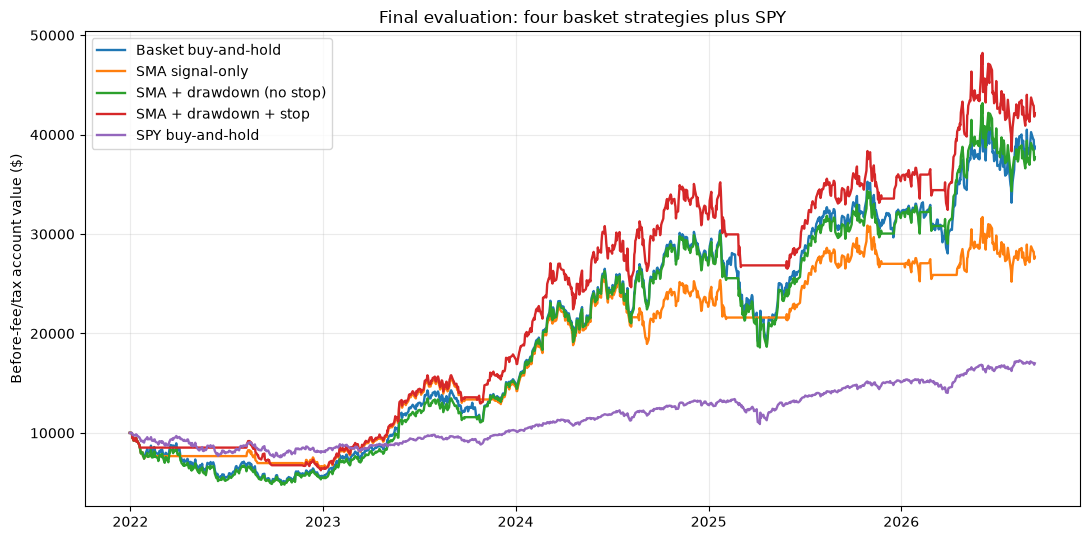


Basket buy-and-hold realised trades
entry_date  exit_date  entry_price  exit_price       entry_reason          exit_reason signal_date  fill_date    gross_pnl  return_pct
2022-01-03 2026-09-11     7.457923   28.930379 buy_and_hold_entry terminal_liquidation         NaT 2026-09-11 28791.470181  287.914702

SMA signal-only realised trades
entry_date  exit_date  entry_price  exit_price entry_reason          exit_reason signal_date  fill_date    gross_pnl  return_pct
2022-01-03 2022-01-28     7.457923    5.718022  trend_entry     sma_bearish_exit  2022-01-27 2022-01-28 -2332.956755  -23.329568
2022-08-09 2022-08-30     4.838873    4.395728  trend_entry     sma_bearish_exit  2022-08-29 2022-08-30  -702.149728   -9.158025
2022-11-23 2023-01-05     4.430939    4.200392  trend_entry     sma_bearish_exit  2023-01-04 2023-01-05  -362.391163   -5.203111
2023-01-11 2023-09-27     4.523468    9.155401  trend_entry     sma_bearish_exit  2023-09-26 2023-09-27  6760.819720  102.397839
2023-11-17 2024

In [14]:
evaluation_results = {
    "Basket buy-and-hold": buyhold_result,
    "SMA signal-only": confirmation_result,
    "SMA + drawdown (no stop)": no_stop_result,
    "SMA + drawdown + stop": risk_result,
    "SPY buy-and-hold": spy_result,
}
evaluation_stats = pd.DataFrame({
    label: strategy_metrics(label, result, spy_result)
    for label, result in evaluation_results.items()
})
print(
    f"BEFORE-FEE/TAX HEAD-TO-HEAD: {EVAL_START.date()} to {EVAL_END.date()} | "
    "$10,000, next-close proxy, no trading fees or tax deducted, terminal liquidation"
)
print(evaluation_stats.round(4).to_string())
plot_net_curves(
    {label: result["equity"] for label, result in evaluation_results.items()},
    "Final evaluation: four basket strategies plus SPY",
)
for label in [
    "Basket buy-and-hold",
    "SMA signal-only",
    "SMA + drawdown (no stop)",
    "SMA + drawdown + stop",
]:
    print(f"\n{label} realised trades")
    print(_display_trades(evaluation_results[label]).to_string(index=False))


### Rule checklist and limitations

- **Shared data path:** `return.csv` is an adjusted-close cache and is read-only
  after the selection cell; only SPY is downloaded for the benchmark.  The
  approved screen is frozen at `TOP_N=50`, `n=3`, with `BLDR`, `MRVL`, and `NVDA`.
- **Shared basket:** all sections use the same equal-weight fixed shares on
  2018-12-31, drift thereafter, and retrospective pre-2018 backcast.  No DCA,
  rebalance, averaging down, leverage, or yearly rotation is introduced.
- **Shared simulator:** condition-based SMA logic is used consistently; there is
  no crossover-event/backtest discrepancy.  Signals use the prior close and
  fill on the next close proxy; no trading fees or tax are deducted, and terminal
  liquidation is executed at no cost.
- **Rules:** trend entries require `fast > slow`; recovery entries require the
  signed drawdown threshold.  Recovery holdings wait for bullish transfer before
  SMA bearish exit.  In the risk section the signed stop has priority and
  applies to every holding; after a stop, both drawdown entries and ordinary
  trend entries stay locked until a fresh bullish SMA crossover after the stop
  fill.  A drawdown reset alone does not unlock the strategy; a permitted normal
  bearish SMA exit does.
- **Risk and interpretation:** daily-close stop execution is not guaranteed.
  The selected basket and its prehistory are retrospective and selection-biased;
  thresholds should be fixed before a genuinely unseen test.  The episode table
  is descriptive and does not establish a margin of safety.
- **Capacity and behaviour:** this is a $10,000 fractional-unit illustration.
  Spreads, slippage, taxes, liquidity, market impact, gaps, and behavioural
  execution risk are not modelled.  No AI or big-data model is used.
